# **Data Normalization Techniques**


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [18]:
!pip install seaborn

In [3]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 198.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 222.4 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [5]:
from sklearn.preprocessing import MinMaxScaler

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [7]:
## Write your code here
# Count duplicate rows across all columns
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display the first few duplicate rows
duplicates = df[df.duplicated()]
print("First few duplicate rows:")
print(duplicates.head())

Number of duplicate rows: 0
First few duplicate rows:
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmi

### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [8]:
## Write your code here
# Count missing values in CodingActivities column
missing_coding = df["CodingActivities"].isnull().sum()
print("Number of missing values in CodingActivities:", missing_coding)

Number of missing values in CodingActivities: 10971


In [9]:
# Percentage of missing values in CodingActivities
missing_coding_percentage = (df["CodingActivities"].isnull().sum() / len(df)) * 100
print("Percentage of missing values in CodingActivities:", missing_coding_percentage)

Percentage of missing values in CodingActivities: 16.765744150862663


In [10]:
# Display rows where CodingActivities is missing
missing_rows = df[df["CodingActivities"].isnull()]
print(missing_rows.head())

    ResponseId                                         MainBranch  \
3            4                              I am learning to code   
4            5                     I am a developer by profession   
5            6                        I code primarily as a hobby   
7            8                              I am learning to code   
13          14  I used to be a developer by profession, but no...   

                   Age                                         Employment  \
3      18-24 years old                                 Student, full-time   
4      18-24 years old                                 Student, full-time   
5   Under 18 years old                                 Student, full-time   
7      18-24 years old  Student, full-time;Not employed, but looking f...   
13     35-44 years old             Not employed, and not looking for work   

   RemoteWork   Check CodingActivities  \
3         NaN  Apples              NaN   
4         NaN  Apples              NaN

##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [11]:
# Count missing values before imputation
print("Missing values before:", df["CodingActivities"].isnull().sum())

Missing values before: 10971


In [12]:
# Count missing values after imputation
print("Missing values after:", df["CodingActivities"].isnull().sum())

print(df["CodingActivities"].head(10))

Missing values after: 10971
0                                                Hobby
1    Hobby;Contribute to open-source projects;Other...
2    Hobby;Contribute to open-source projects;Other...
3                                                  NaN
4                                                  NaN
5                                                  NaN
6                         I don’t code outside of work
7                                                  NaN
8                                                Hobby
9                             Bootstrapping a business
Name: CodingActivities, dtype: str


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [13]:
# Find columns related to compensation or salary
comp_columns = [col for col in df.columns if "Comp" in col or "Salary" in col]
print("Compensation-related columns:", comp_columns)

Compensation-related columns: ['CompTotal', 'AIComplex', 'ConvertedCompYearly']


In [14]:
# Summary statistics for ConvertedCompYearly
print(df["ConvertedCompYearly"].describe())

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


In [16]:
# Count missing values in ConvertedCompYearly
missing_comp = df["ConvertedCompYearly"].isnull().sum()
print("Missing values in ConvertedCompYearly:", missing_comp)

Missing values in ConvertedCompYearly: 42002


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [15]:
# Initialize scaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to ConvertedCompYearly
df["ConvertedCompYearly_MinMax"] = scaler.fit_transform(df[["ConvertedCompYearly"]])

In [16]:
# Preview original vs normalized values
print(df[["ConvertedCompYearly", "ConvertedCompYearly_MinMax"]].head())

   ConvertedCompYearly  ConvertedCompYearly_MinMax
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN


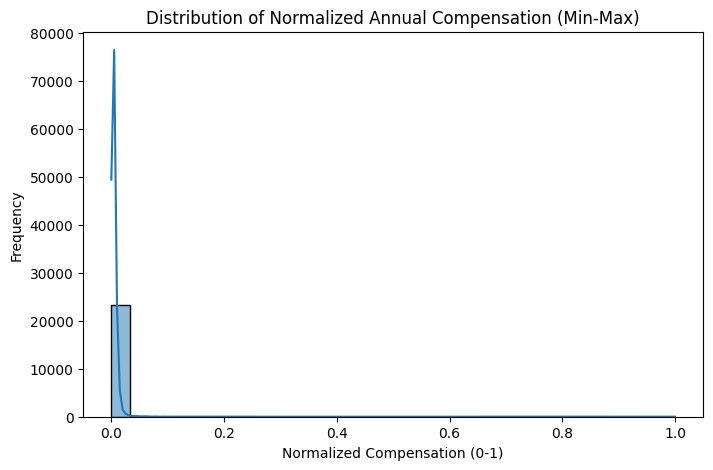

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["ConvertedCompYearly_MinMax"].dropna(), bins=30, kde=True)
plt.title("Distribution of Normalized Annual Compensation (Min-Max)")
plt.xlabel("Normalized Compensation (0-1)")
plt.ylabel("Frequency")
plt.show()

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
# Initialize scaler
scaler = StandardScaler()

# Apply Z-score normalization to ConvertedCompYearly
df["ConvertedCompYearly_Zscore"] = scaler.fit_transform(df[["ConvertedCompYearly"]])

In [23]:
# Preview original vs normalized values
print(df[["ConvertedCompYearly", "ConvertedCompYearly_Zscore"]].head())

   ConvertedCompYearly  ConvertedCompYearly_Zscore
0                  NaN                         NaN
1                  NaN                         NaN
2                  NaN                         NaN
3                  NaN                         NaN
4                  NaN                         NaN


Text(0, 0.5, 'Frequency')

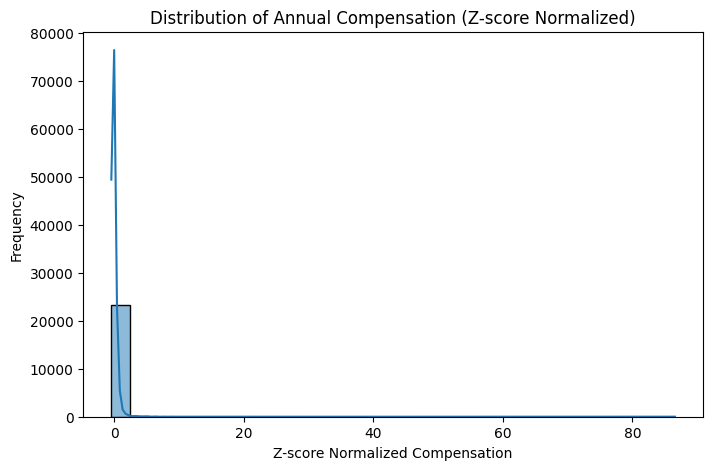

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["ConvertedCompYearly_Zscore"].dropna(), bins=30, kde=True)
plt.title("Distribution of Annual Compensation (Z-score Normalized)")
plt.xlabel("Z-score Normalized Compensation")
plt.ylabel("Frequency")

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


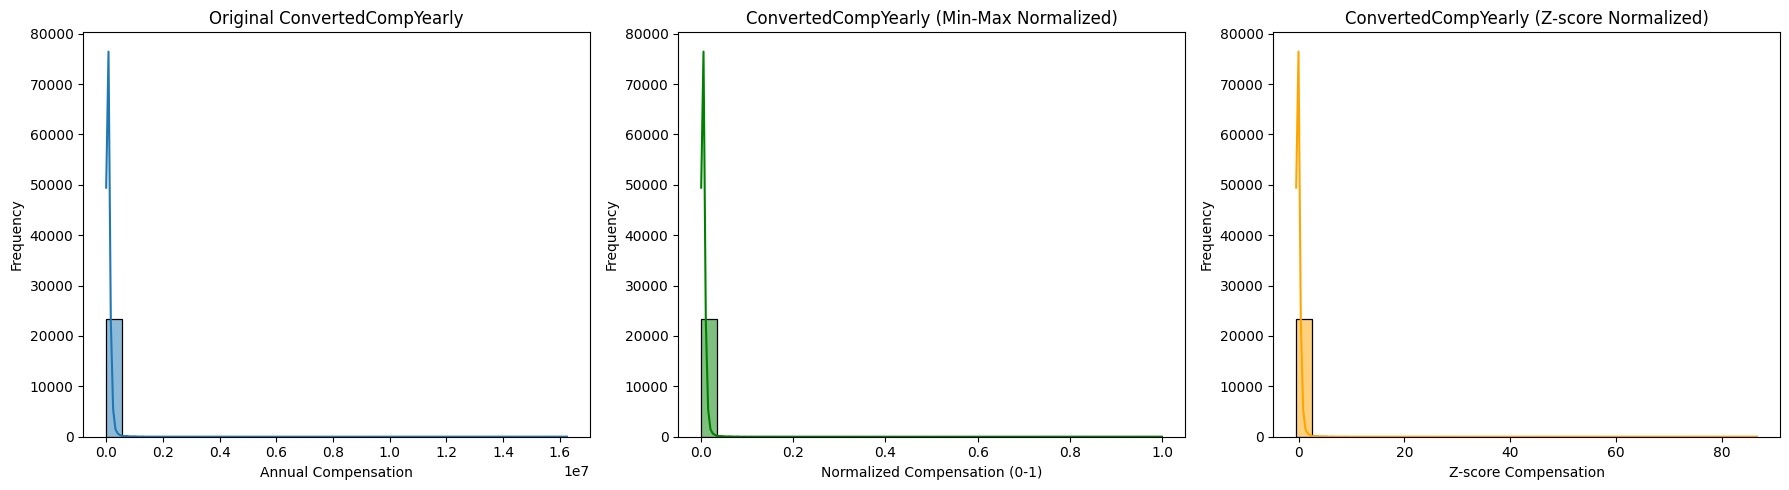

In [25]:
# Set up figure with 3 subplots
plt.figure(figsize=(18,5))

# Original Compensation
plt.subplot(1,3,1)
sns.histplot(df["ConvertedCompYearly"].dropna(), bins=30, kde=True)
plt.title("Original ConvertedCompYearly")
plt.xlabel("Annual Compensation")
plt.ylabel("Frequency")

# Min-Max Normalized Compensation
plt.subplot(1,3,2)
sns.histplot(df["ConvertedCompYearly_MinMax"].dropna(), bins=30, kde=True, color="green")
plt.title("ConvertedCompYearly (Min-Max Normalized)")
plt.xlabel("Normalized Compensation (0-1)")
plt.ylabel("Frequency")

# Z-score Normalized Compensation
plt.subplot(1,3,3)
sns.histplot(df["ConvertedCompYearly_Zscore"].dropna(), bins=30, kde=True, color="orange")
plt.title("ConvertedCompYearly (Z-score Normalized)")
plt.xlabel("Z-score Compensation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.
